In [29]:
# =========================================
# 1. IMPORT LIBRARIES
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import xgboost as xgb

# better plots
sns.set(style="whitegrid")


# =========================================
# 2. LOAD DATASET
# =========================================

df = pd.read_csv("FYP2.csv")
print("Dataset Loaded Successfully!")
df.head()


Dataset Loaded Successfully!


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [30]:
# =========================================
# 3. BASIC DATA EXPLORATION
# =========================================

print("Shape:", df.shape)
print("\nColumns:", df.columns)
print("\nMissing Values:\n", df.isna().sum())

df.describe()


Shape: (10000, 14)

Columns: Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

Missing Values:
 UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


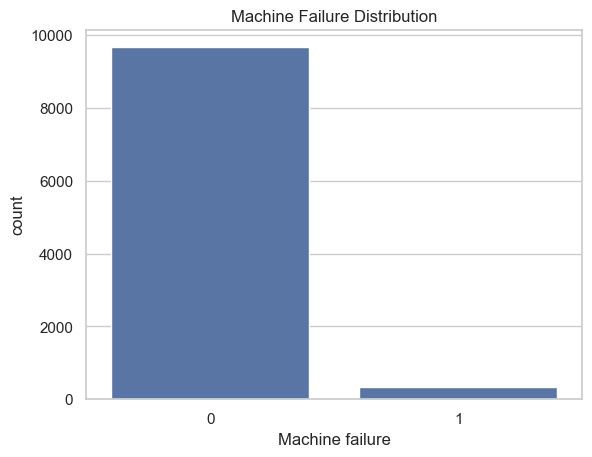

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [31]:
# =========================================
# 4. CHECK CLASS BALANCE
# =========================================

sns.countplot(x=df["Machine failure"])
plt.title("Machine Failure Distribution")
plt.show()

df["Machine failure"].value_counts()


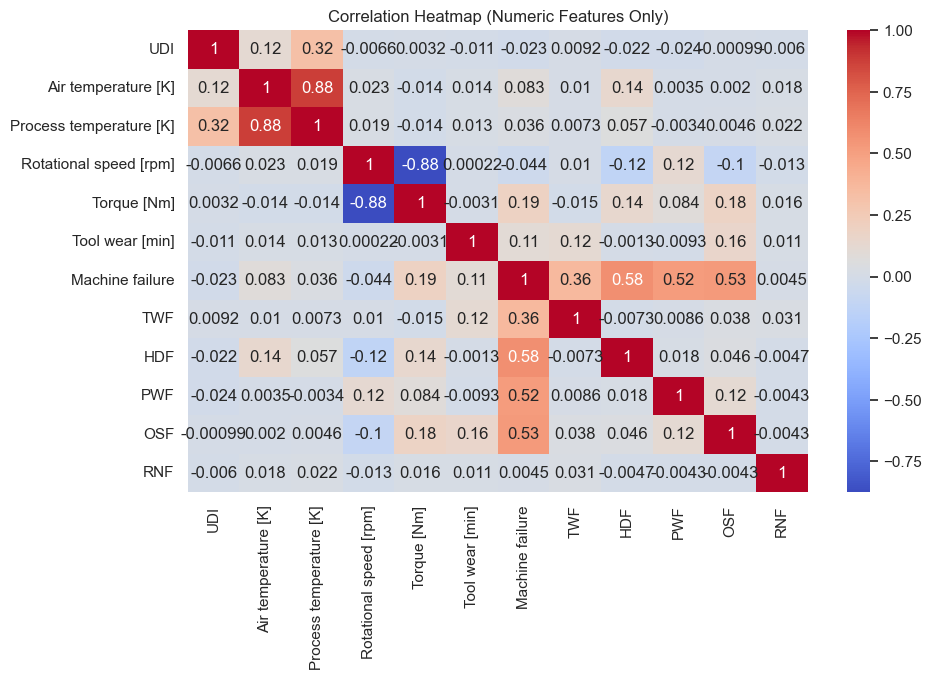

In [32]:
# =========================================
# 5. CORRELATION ANALYSIS
# =========================================

plt.figure(figsize=(10,6))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()



In [33]:
# =========================================
# 6. SELECT FEATURES & LABEL
# =========================================

features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

X = df[features]
y = df["Machine failure"]

print("Features and Label Separated.")


Features and Label Separated.


In [34]:
# =========================================
# 7. NORMALIZE FEATURES
# =========================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature Scaling Completed.")


Feature Scaling Completed.


In [35]:
# =========================================
# 8. TRAIN-TEST SPLIT
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Train/Test Split Completed.")


Train/Test Split Completed.


In [36]:
# =============================================
# 6. HANDLE IMBALANCE USING scale_pos_weight
# =============================================
count_class_0 = (y == 0).sum()
count_class_1 = (y == 1).sum()

scale_pos_weight = count_class_0 / count_class_1
print("scale_pos_weight =", scale_pos_weight)

scale_pos_weight = 28.49852507374631


In [37]:
# =========================================
# 9. TRAIN RANDOM FOREST MODEL
# =========================================

model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    learning_rate=0.05,
    n_estimators=300,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,   # IMBALANCE FIX
    random_state=42
)

model.fit(X_train, y_train)
print("XGBoost Training Completed.")


XGBoost Training Completed.



Model Accuracy: 0.978

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1939
           1       0.61      0.75      0.68        61

    accuracy                           0.98      2000
   macro avg       0.80      0.87      0.83      2000
weighted avg       0.98      0.98      0.98      2000



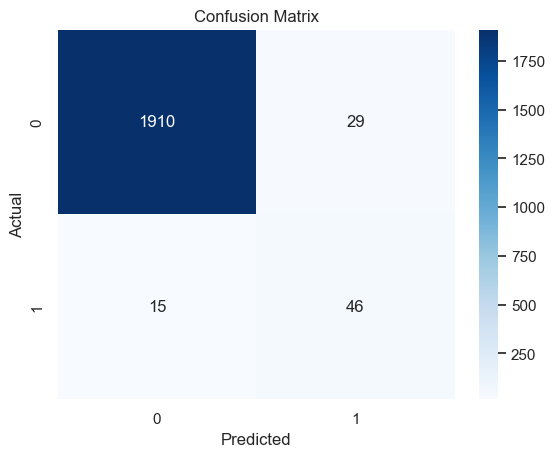

In [38]:
# =========================================
# 10. MODEL PREDICTION & EVALUATION
# =========================================

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("\nModel Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


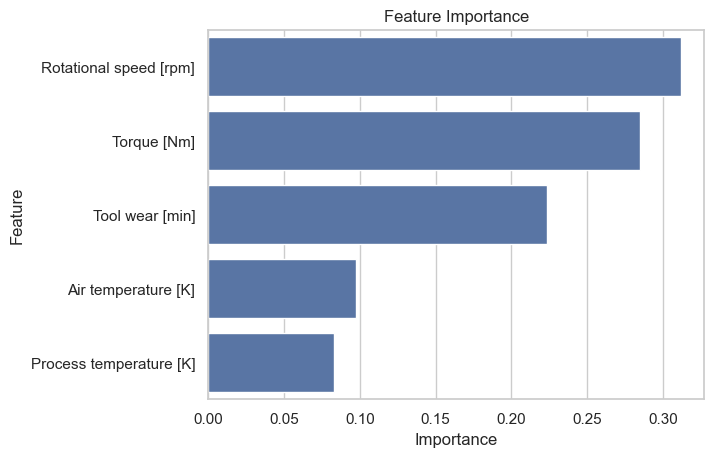

,Feature,Importance
2,Rotational speed [rpm],0.311776
3,Torque [Nm],0.284928
4,Tool wear [min],0.223392
0,Air temperature [K],0.097121
1,Process temperature [K],0.082783


In [39]:
# =========================================
# 11. FEATURE IMPORTANCE
# =========================================

importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

sns.barplot(x="Importance", y="Feature", data=feature_importance_df)
plt.title("Feature Importance")
plt.show()

feature_importance_df


In [40]:
# =========================================
# 12. SAVE MODEL & SCALER
# =========================================

joblib.dump(model, "trained_model_xgb.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and Scaler Saved Successfully!")


Model and Scaler Saved Successfully!


In [ ]:
import os
os.getcwd()


'c:\\NDG\\FYP2'

: 